# Comparando Modelos de Classificação Multiclasse
## Decision Tree vs Random Forest vs XGBoost

Neste notebook, vamos atacar o **mesmo problema** do notebook anterior — prever o **risco de crédito** (`baixo`, `medio`, `alto`) — mas agora usando **três algoritmos baseados em árvores**:

1. **Decision Tree** — uma única árvore de decisão. Simples e fácil de interpretar.
2. **Random Forest** — um *ensemble* de várias árvores treinadas em amostras aleatórias dos dados. Reduz overfitting da árvore individual.
3. **XGBoost** — *gradient boosting* otimizado, que treina árvores **sequencialmente**, cada uma corrigindo os erros da anterior. Costuma ser o estado da arte em dados tabulares.

Ao final, vamos comparar acurácia, F1 macro, importância das variáveis e tempo de treino para entender as forças e fraquezas de cada um.

> **Observação:** modelos baseados em árvore **não exigem padronização das features** — eles dividem o espaço por limiares, e a escala não importa.

## 1. Importação das Bibliotecas

In [1]:
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, f1_score,
    confusion_matrix, classification_report,
)

sns.set_style('whitegrid')

## 2. Carregamento dos Dados

In [2]:
df = pd.read_csv('dados_risco_credito.csv')
print(f'Dimensões: {df.shape[0]} linhas × {df.shape[1]} colunas')
df.head()

Dimensões: 600 linhas × 7 colunas


,renda_mensal,score_credito,divida_atual,idade,tempo_emprego_anos,num_dependentes,risco_credito
0,4803.12,570,22747.50,68,0.6,4,alto
1,26725.15,317,38926.49,55,4.7,2,medio
2,15444.06,356,58074.40,21,20.0,5,alto
3,5536.71,379,3456.06,48,18.9,3,medio
4,5851.67,554,55371.86,57,28.1,3,alto


## 3. Preparação dos Dados

- Codificamos a variável alvo com `LabelEncoder`.
- Dividimos em treino/teste (estratificado).
- **Não precisamos padronizar** (modelos de árvore são invariantes à escala).

In [3]:
le = LabelEncoder()
y = le.fit_transform(df['risco_credito'])
X = df.drop(columns='risco_credito')

print('Mapeamento das classes:')
for i, classe in enumerate(le.classes_):
    print(f'  {classe} → {i}')

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'\nTreino: {X_treino.shape[0]} | Teste: {X_teste.shape[0]}')

Mapeamento das classes:
  alto → 0
  baixo → 1
  medio → 2

Treino: 480 | Teste: 120


Vamos criar um dicionário para guardar os resultados de cada modelo, de modo a comparar todos no final.

In [4]:
resultados = {}

def avaliar(nome, modelo, t_treino):
    y_pred = modelo.predict(X_teste)
    acc = accuracy_score(y_teste, y_pred)
    f1_macro = f1_score(y_teste, y_pred, average='macro')
    f1_weighted = f1_score(y_teste, y_pred, average='weighted')
    resultados[nome] = {
        'modelo': modelo,
        'y_pred': y_pred,
        'acuracia': acc,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted,
        'tempo_treino_s': t_treino,
    }
    print(f'{nome}:')
    print(f'  Acurácia:        {acc:.4f}')
    print(f'  F1 macro:        {f1_macro:.4f}')
    print(f'  F1 weighted:     {f1_weighted:.4f}')
    print(f'  Tempo de treino: {t_treino:.3f} s')

## 4. Decision Tree (Árvore de Decisão)

Uma árvore de decisão divide os dados em "folhas" através de perguntas binárias sobre as features (`score_credito > 600?`, `divida_atual > 20000?`, etc.). É **fácil de interpretar**, mas tende a **superajustar** (decorar) o conjunto de treino.

Limitamos a profundidade máxima (`max_depth=5`) para evitar overfitting.

In [5]:
t0 = time.time()
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_treino, y_treino)
t_dt = time.time() - t0

avaliar('Decision Tree', dt, t_dt)

Decision Tree:
  Acurácia:        0.6750
  F1 macro:        0.6653
  F1 weighted:     0.6677
  Tempo de treino: 0.002 s


### 4.1 Visualização da Árvore

Uma das grandes vantagens da árvore: dá pra **enxergar** as decisões. Mostramos uma versão limitada (profundidade 3) para caber na tela.

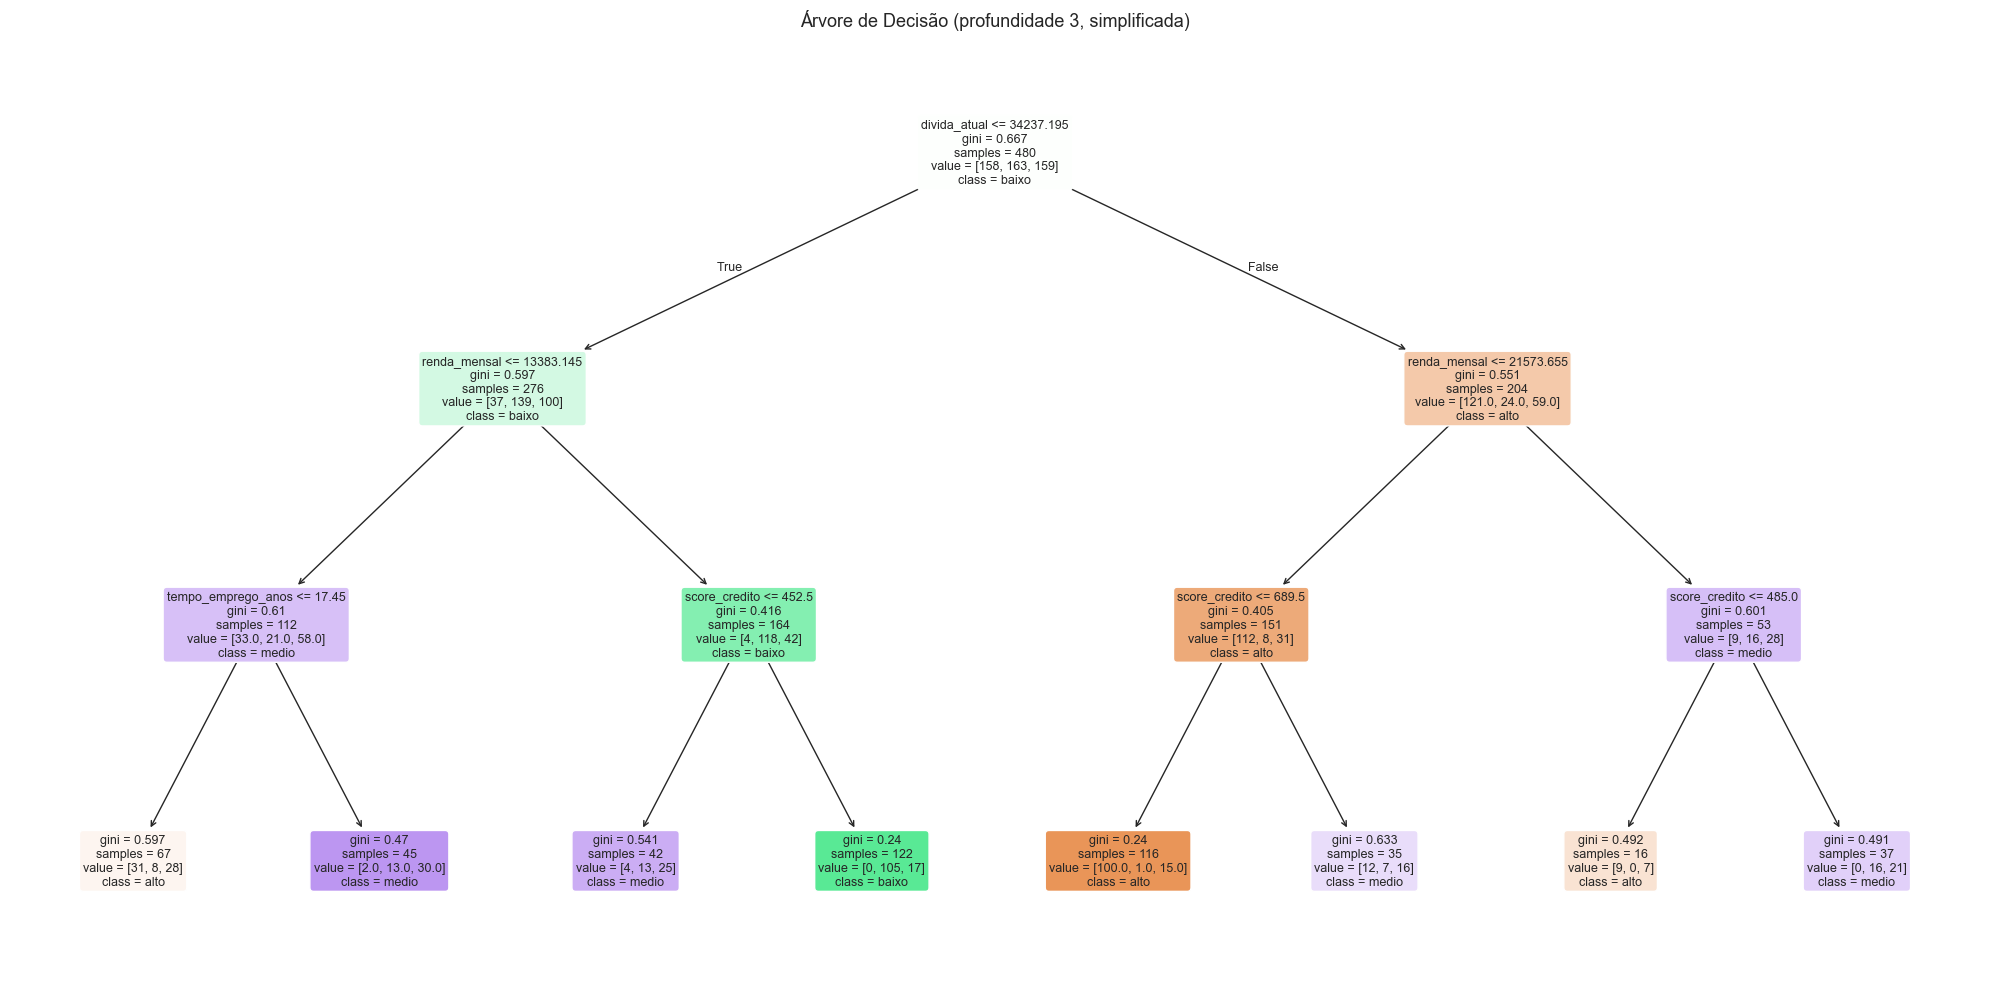

In [6]:
fig, ax = plt.subplots(figsize=(20, 10))
plot_tree(
    DecisionTreeClassifier(max_depth=3, random_state=42).fit(X_treino, y_treino),
    feature_names=X.columns,
    class_names=le.classes_,
    filled=True,
    rounded=True,
    fontsize=9,
    ax=ax,
)
plt.title('Árvore de Decisão (profundidade 3, simplificada)', fontsize=13)
plt.tight_layout()
plt.show()

### 4.2 Importância das Variáveis (Decision Tree)

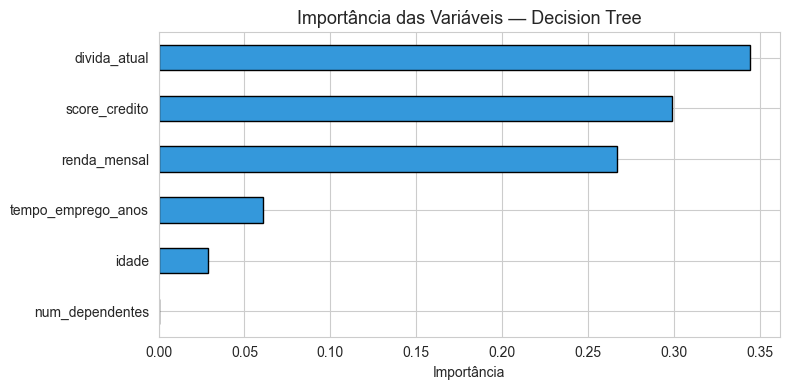

In [7]:
imp_dt = pd.Series(dt.feature_importances_, index=X.columns).sort_values()

plt.figure(figsize=(8, 4))
imp_dt.plot(kind='barh', color='#3498db', edgecolor='black')
plt.title('Importância das Variáveis — Decision Tree', fontsize=13)
plt.xlabel('Importância')
plt.tight_layout()
plt.show()

## 5. Random Forest

Random Forest treina **muitas árvores** (`n_estimators` por padrão), cada uma vendo:
- uma **amostra aleatória** dos dados (bootstrap);
- um **subconjunto aleatório** das features em cada nó.

A previsão final é a **votação majoritária** (em classificação). Esse esquema reduz drasticamente o overfitting da árvore individual e geralmente entrega resultados muito robustos.

In [8]:
t0 = time.time()
rf = RandomForestClassifier(n_estimators=200, max_depth=None,
                            random_state=42, n_jobs=-1)
rf.fit(X_treino, y_treino)
t_rf = time.time() - t0

avaliar('Random Forest', rf, t_rf)

Random Forest:
  Acurácia:        0.7583
  F1 macro:        0.7576
  F1 weighted:     0.7593
  Tempo de treino: 0.107 s


### 5.1 Importância das Variáveis (Random Forest)

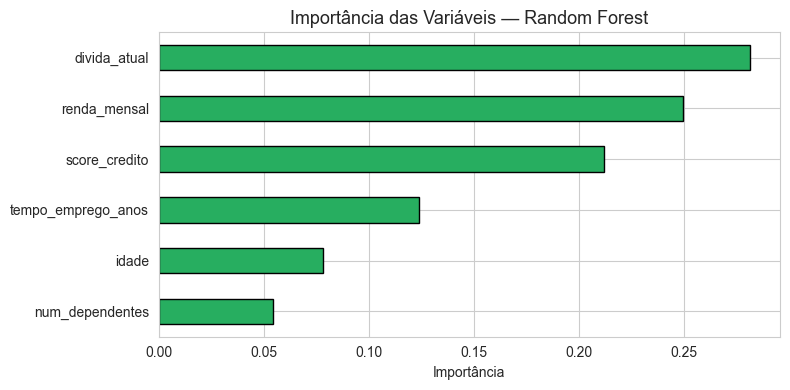

In [9]:
imp_rf = pd.Series(rf.feature_importances_, index=X.columns).sort_values()

plt.figure(figsize=(8, 4))
imp_rf.plot(kind='barh', color='#27ae60', edgecolor='black')
plt.title('Importância das Variáveis — Random Forest', fontsize=13)
plt.xlabel('Importância')
plt.tight_layout()
plt.show()

## 6. XGBoost (eXtreme Gradient Boosting)

XGBoost é uma das implementações mais populares de **gradient boosting**. A ideia:

1. Treine uma primeira árvore fraca.
2. Veja onde ela errou.
3. Treine a próxima árvore para **corrigir esses erros** (atribuindo mais peso aos exemplos errados).
4. Repita por várias rodadas.

O resultado é um conjunto de árvores que, somadas, atinge um desempenho geralmente superior ao Random Forest em problemas tabulares.

In [10]:
t0 = time.time()
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.1,
    objective='multi:softprob',
    num_class=3,
    random_state=42,
    n_jobs=-1,
    eval_metric='mlogloss',
)
xgb.fit(X_treino, y_treino)
t_xgb = time.time() - t0

avaliar('XGBoost', xgb, t_xgb)

XGBoost:
  Acurácia:        0.8000
  F1 macro:        0.8010
  F1 weighted:     0.8024
  Tempo de treino: 1.229 s


### 6.1 Importância das Variáveis (XGBoost)

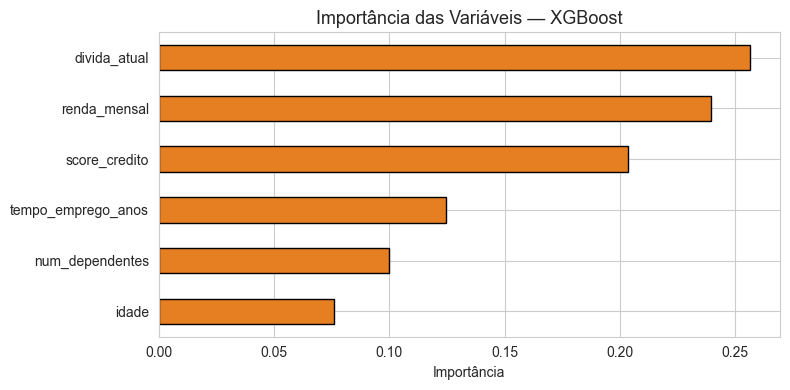

In [11]:
imp_xgb = pd.Series(xgb.feature_importances_, index=X.columns).sort_values()

plt.figure(figsize=(8, 4))
imp_xgb.plot(kind='barh', color='#e67e22', edgecolor='black')
plt.title('Importância das Variáveis — XGBoost', fontsize=13)
plt.xlabel('Importância')
plt.tight_layout()
plt.show()

## 7. Comparação dos Três Modelos

### 7.1 Tabela Resumo de Métricas

In [12]:
resumo = pd.DataFrame({
    nome: {
        'Acurácia': r['acuracia'],
        'F1 Macro': r['f1_macro'],
        'F1 Weighted': r['f1_weighted'],
        'Tempo de Treino (s)': r['tempo_treino_s'],
    } for nome, r in resultados.items()
}).T

resumo.round(4)

,Acurácia,F1 Macro,F1 Weighted,Tempo de Treino (s)
Decision Tree,0.6750,0.6653,0.6677,0.0019
Random Forest,0.7583,0.7576,0.7593,0.1069
XGBoost,0.8000,0.8010,0.8024,1.2286


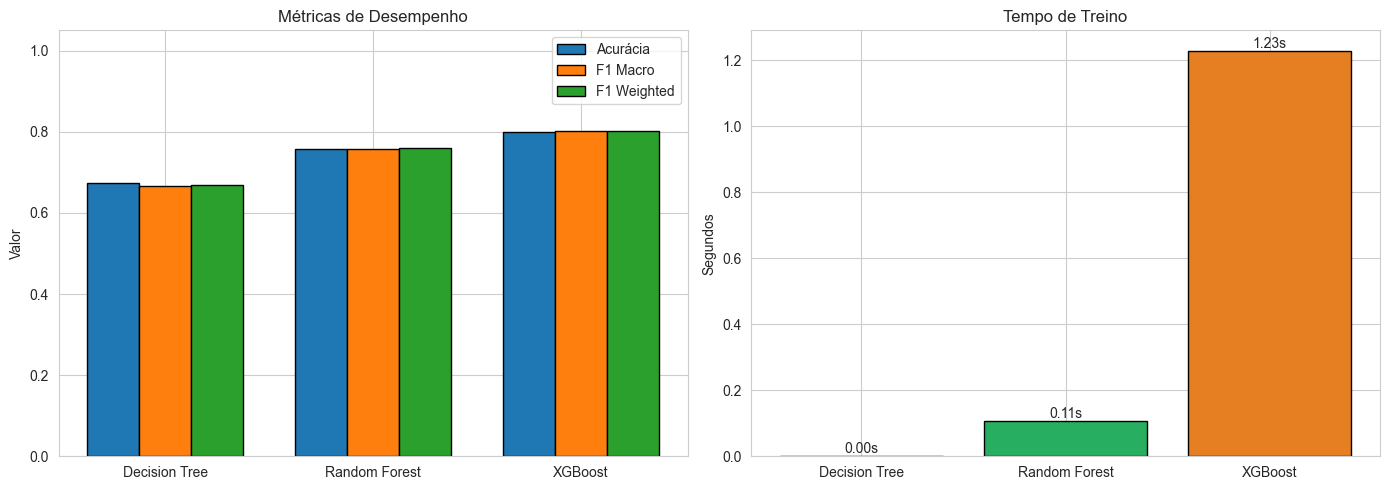

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Acurácia + F1
metricas = ['Acurácia', 'F1 Macro', 'F1 Weighted']
x = np.arange(len(resumo.index))
largura = 0.25
cores_m = ['#3498db', '#27ae60', '#e67e22']

for i, met in enumerate(metricas):
    axes[0].bar(x + i * largura, resumo[met], largura, label=met,
                edgecolor='black')
axes[0].set_xticks(x + largura)
axes[0].set_xticklabels(resumo.index)
axes[0].set_ylabel('Valor')
axes[0].set_title('Métricas de Desempenho')
axes[0].set_ylim(0, 1.05)
axes[0].legend()

# Tempo de treino
axes[1].bar(resumo.index, resumo['Tempo de Treino (s)'],
            color=cores_m, edgecolor='black')
axes[1].set_ylabel('Segundos')
axes[1].set_title('Tempo de Treino')
for i, v in enumerate(resumo['Tempo de Treino (s)']):
    axes[1].text(i, v, f'{v:.2f}s', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

### 7.2 Matrizes de Confusão Lado a Lado

Mostrar as três matrizes lado a lado deixa fácil ver **onde cada modelo erra mais**.

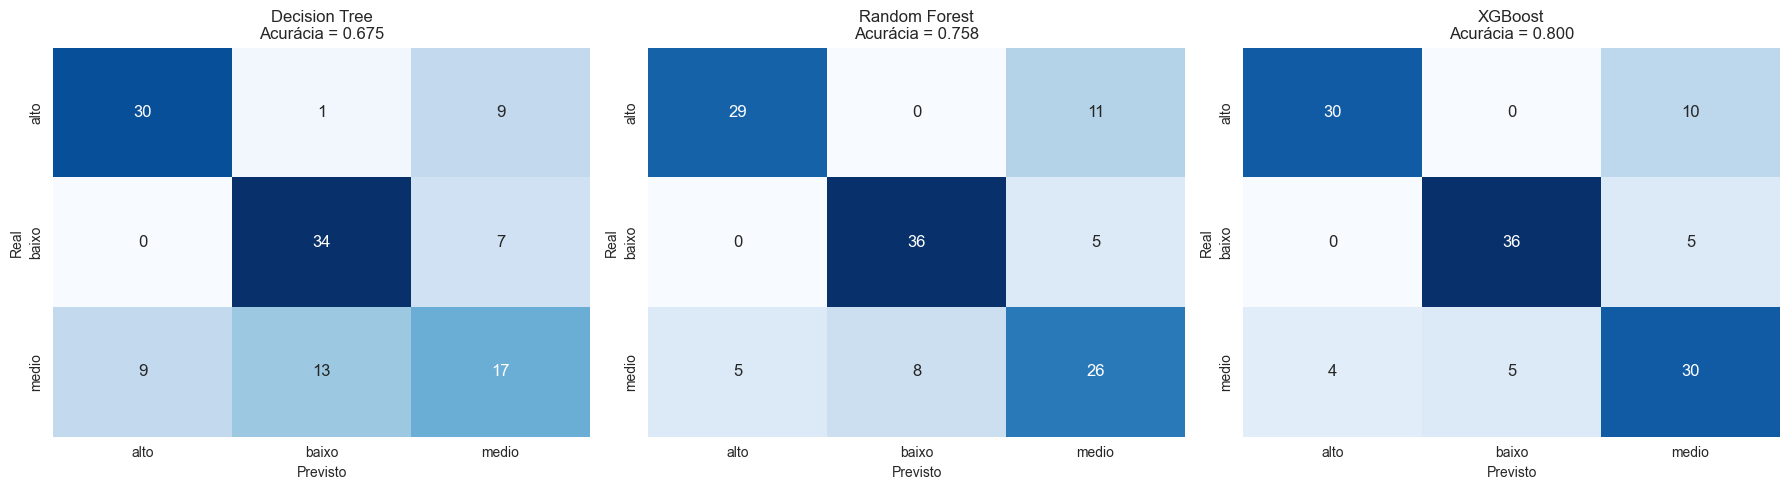

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (nome, r) in zip(axes, resultados.items()):
    cm = confusion_matrix(y_teste, r['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le.classes_, yticklabels=le.classes_,
                cbar=False, annot_kws={'size': 12}, ax=ax)
    ax.set_title(f'{nome}\nAcurácia = {r["acuracia"]:.3f}', fontsize=12)
    ax.set_xlabel('Previsto')
    ax.set_ylabel('Real')

plt.tight_layout()
plt.show()

### 7.3 Importância das Variáveis — Comparação

Essa visualização mostra como **cada modelo prioriza variáveis diferentes**. As mais importantes para um podem não ser para outro, e isso é uma informação valiosa.

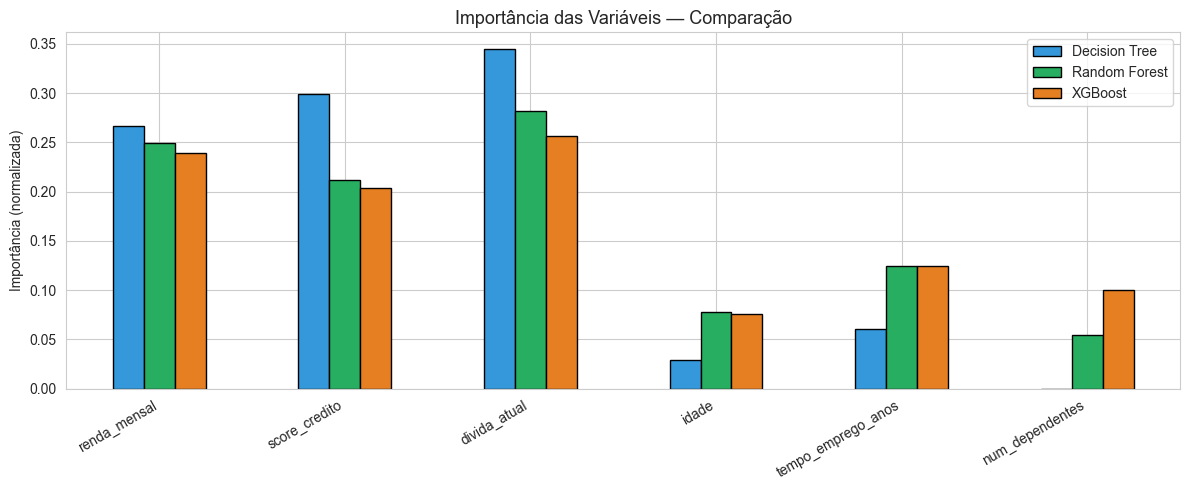


Valores numéricos:


,Decision Tree,Random Forest,XGBoost
renda_mensal,0.267,0.249,0.239
score_credito,0.299,0.212,0.203
divida_atual,0.345,0.282,0.257
idade,0.029,0.078,0.076
tempo_emprego_anos,0.061,0.124,0.125
num_dependentes,0.000,0.054,0.100


In [15]:
importancias = pd.DataFrame({
    'Decision Tree': dt.feature_importances_,
    'Random Forest': rf.feature_importances_,
    'XGBoost':       xgb.feature_importances_,
}, index=X.columns)

ax = importancias.plot(kind='bar', figsize=(12, 5),
                       color=['#3498db', '#27ae60', '#e67e22'],
                       edgecolor='black')
ax.set_title('Importância das Variáveis — Comparação', fontsize=13)
ax.set_ylabel('Importância (normalizada)')
ax.set_xlabel('')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

print('\nValores numéricos:')
importancias.round(3)

### 7.4 Relatório Detalhado por Modelo

Vamos imprimir o `classification_report` de cada modelo para ver precisão, recall e F1 **por classe**.

In [16]:
for nome, r in resultados.items():
    print(f'\n{"=" * 60}')
    print(f'  {nome}')
    print('=' * 60)
    print(classification_report(y_teste, r['y_pred'],
                                target_names=le.classes_))


  Decision Tree
              precision    recall  f1-score   support

        alto       0.77      0.75      0.76        40
       baixo       0.71      0.83      0.76        41
       medio       0.52      0.44      0.47        39

    accuracy                           0.68       120
   macro avg       0.66      0.67      0.67       120
weighted avg       0.67      0.68      0.67       120


  Random Forest
              precision    recall  f1-score   support

        alto       0.85      0.72      0.78        40
       baixo       0.82      0.88      0.85        41
       medio       0.62      0.67      0.64        39

    accuracy                           0.76       120
   macro avg       0.76      0.76      0.76       120
weighted avg       0.77      0.76      0.76       120


  XGBoost
              precision    recall  f1-score   support

        alto       0.88      0.75      0.81        40
       baixo       0.88      0.88      0.88        41
       medio       0.67      0

## 8. Validação Cruzada (5 folds)

Os números acima vêm de **uma única divisão** treino/teste — podem ser otimistas ou pessimistas por sorte. A **validação cruzada** divide os dados em K partes, treinando K vezes (cada parte é teste uma vez) e fornece uma estimativa mais confiável.

In [17]:
modelos = {
    'Decision Tree': DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.1,
                             objective='multi:softprob', num_class=3,
                             random_state=42, n_jobs=-1, eval_metric='mlogloss'),
}

print(f'{"Modelo":<16s}{"Acurácia média":<20s}{"Desvio padrão":<15s}')
print('-' * 51)
for nome, mod in modelos.items():
    scores = cross_val_score(mod, X, y, cv=5, scoring='accuracy', n_jobs=-1)
    print(f'{nome:<16s}{scores.mean():<20.4f}{scores.std():<15.4f}')

Modelo          Acurácia média      Desvio padrão  
---------------------------------------------------


Decision Tree   0.6800              0.0145         


Random Forest   0.8000              0.0190         


XGBoost         0.8100              0.0260         


## 9. Conclusão

| Aspecto                      | Decision Tree            | Random Forest            | XGBoost                  |
|------------------------------|--------------------------|--------------------------|--------------------------|
| **Interpretabilidade**       | Alta (visualizável)      | Média                    | Baixa (black box)        |
| **Risco de overfitting**     | Alto (sem regularização) | Baixo                    | Médio (precisa tunar)    |
| **Tempo de treino**          | Muito rápido             | Médio                    | Médio/rápido             |
| **Hiperparâmetros**          | Poucos                   | Poucos                   | Muitos (mais flexível)   |
| **Desempenho típico**        | Razoável                 | Forte                    | Geralmente o melhor      |

### Quando usar cada um?

- **Decision Tree**: protótipos rápidos, quando a interpretabilidade é o principal requisito (ex.: explicar a decisão para um cliente ou regulador).
- **Random Forest**: linha de base sólida — funciona "out-of-the-box" com pouquíssimo ajuste e raramente decepciona.
- **XGBoost**: quando se quer espremer ao máximo o desempenho. Requer mais cuidado com hiperparâmetros (learning rate, profundidade, regularização).

### Próximos passos sugeridos

1. **Tuning de hiperparâmetros** com `GridSearchCV` ou `RandomizedSearchCV`.
2. Avaliar com **mais dados** — datasets pequenos favorecem modelos simples.
3. Tentar técnicas de **balanceamento** (SMOTE, class_weight) se as classes forem muito desbalanceadas.
4. Combinar modelos via **stacking** ou **voting**.